# Practica Evaluativa
Resolucion de los ejercicios 1 al 6 con la misma logica de clase (OpenCV, NumPy y Matplotlib).

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

salida = Path('salidas_practica5_pdf')
salida.mkdir(exist_ok=True)

def cargar_imagen(base):
    candidatos = [f'{base}.jpg', f'{base}.jpeg', f'{base}.jpg.jpeg', f'{base}.png', base]
    for nombre in candidatos:
        img = cv2.imread(nombre, cv2.IMREAD_COLOR)
        if img is not None:
            return img, nombre
    raise FileNotFoundError(f'No se encontro la imagen para base: {base}')

## Ejercicio 1
Recorte del punto de interes en imagenP.

In [ ]:
img_p_bgr, ruta_p = cargar_imagen('imagenP')
img_p_rgb = cv2.cvtColor(img_p_bgr, cv2.COLOR_BGR2RGB)

x, y, w, h = 565, 415, 240, 320
recorte = img_p_rgb[y:y+h, x:x+w]

cv2.imwrite(str(salida / 'ej1_recorte.png'), cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title(f'Original ({ruta_p})')
plt.imshow(img_p_rgb)
plt.axis('on')
plt.subplot(1, 2, 2)
plt.title('Recorte punto de interes')
plt.imshow(recorte)
plt.axis('on')
plt.tight_layout()
plt.show()

## Ejercicio 2
Degradado lineal a color con la misma gama mostrada en el ejemplo.

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

h, w = 256, 250
base = np.tile(np.linspace(0, 1, h, dtype=np.float32)[:, None], (1, w))

colores = [
    (68/255, 1/255, 84/255),
    (59/255, 82/255, 139/255),
    (33/255, 145/255, 140/255),
    (94/255, 201/255, 98/255),
    (253/255, 231/255, 37/255)
]
cmap_lineal = LinearSegmentedColormap.from_list('degradado_clase', colores, N=256)

plt.figure(figsize=(5, 4))
plt.title('Degradado Lineal')
plt.imshow(base, cmap=cmap_lineal, aspect='auto')
plt.axis('on')
plt.tight_layout()
plt.show()

plt.imsave(salida / 'ej2_degradado_lineal.png', base, cmap=cmap_lineal)

## Ejercicio 3
Tablero de ajedrez con casillas de 100x100 px.

In [ ]:
tam_casilla = 100
n = 8
tablero = np.zeros((n * tam_casilla, n * tam_casilla), dtype=np.uint8)

for i in range(n):
    for j in range(n):
        if (i + j) % 2 == 0:
            tablero[i*tam_casilla:(i+1)*tam_casilla, j*tam_casilla:(j+1)*tam_casilla] = 255

cv2.imwrite(str(salida / 'ej3_tablero_100px.png'), tablero)

plt.figure(figsize=(6, 6))
plt.title('Tablero de ajedrez (100x100 por casilla)')
plt.imshow(tablero, cmap='gray', vmin=0, vmax=255)
plt.axis('on')
plt.show()

## Ejercicio 4
Aplicar posterizacion, solarizacion y todas las paletas de falso color al degradado del ejercicio 2; guardar todos los resultados.

In [ ]:
def posterizar_rgb(imagen_rgb, niveles):
    factor = 255 / niveles
    return (np.round(imagen_rgb / factor) * factor).clip(0, 255).astype(np.uint8)

def solarizar_rgb(imagen_rgb, umbral):
    return np.where(imagen_rgb < umbral, imagen_rgb, 255 - imagen_rgb).astype(np.uint8)

degradado_rgb = (plt.cm.viridis(base)[:, :, :3] * 255).astype(np.uint8)
degradado_gray = cv2.cvtColor(degradado_rgb, cv2.COLOR_RGB2GRAY)

img_poster = posterizar_rgb(degradado_rgb, niveles=6)
img_solar = solarizar_rgb(degradado_rgb, umbral=127)

cv2.imwrite(str(salida / 'ej4_posterizada.png'), cv2.cvtColor(img_poster, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(salida / 'ej4_solarizada.png'), cv2.cvtColor(img_solar, cv2.COLOR_RGB2BGR))

mapas = {
    'AUTUMN': cv2.COLORMAP_AUTUMN,
    'BONE': cv2.COLORMAP_BONE,
    'JET': cv2.COLORMAP_JET,
    'WINTER': cv2.COLORMAP_WINTER,
    'RAINBOW': cv2.COLORMAP_RAINBOW,
    'OCEAN': cv2.COLORMAP_OCEAN,
    'SUMMER': cv2.COLORMAP_SUMMER,
    'SPRING': cv2.COLORMAP_SPRING,
    'COOL': cv2.COLORMAP_COOL,
    'HSV': cv2.COLORMAP_HSV,
    'PINK': cv2.COLORMAP_PINK,
    'HOT': cv2.COLORMAP_HOT,
    'PARULA': cv2.COLORMAP_PARULA,
    'MAGMA': cv2.COLORMAP_MAGMA,
    'INFERNO': cv2.COLORMAP_INFERNO,
    'PLASMA': cv2.COLORMAP_PLASMA,
    'VIRIDIS': cv2.COLORMAP_VIRIDIS,
    'CIVIDIS': cv2.COLORMAP_CIVIDIS,
    'TWILIGHT': cv2.COLORMAP_TWILIGHT,
    'TWILIGHT_SHIFTED': cv2.COLORMAP_TWILIGHT_SHIFTED,
    'TURBO': cv2.COLORMAP_TURBO,
    'DEEPGREEN': cv2.COLORMAP_DEEPGREEN
}

falso_dir = salida / 'ej4_falso_color'
falso_dir.mkdir(exist_ok=True)

for nombre, codigo in mapas.items():
    falso_bgr = cv2.applyColorMap(degradado_gray, codigo)
    cv2.imwrite(str(falso_dir / f'{nombre}.png'), falso_bgr)

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.title('Degradado base')
plt.imshow(degradado_rgb)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Posterizada')
plt.imshow(img_poster)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Solarizada')
plt.imshow(img_solar)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Paletas guardadas: {len(mapas)} en {falso_dir}')

## Ejercicio 5
Aplicar un degradado lineal sobre imagen1.

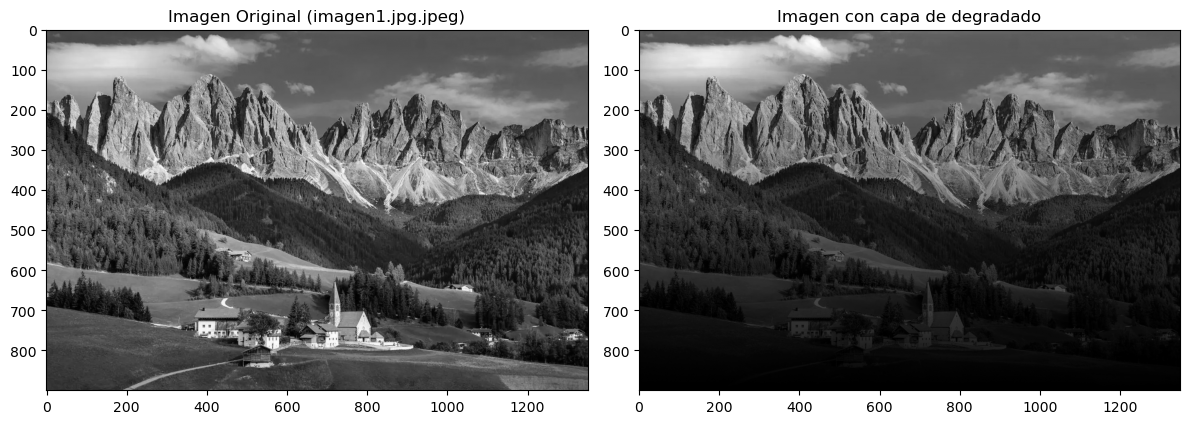

In [47]:
from matplotlib.colors import LinearSegmentedColormap

img1_bgr, ruta_1 = cargar_imagen('imagen1')
img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)

h, w = 256, 250
base = np.tile(np.linspace(1, 0, h, dtype=np.float32)[:, None], (1, w))

colores = [
    (255/255, 255/255, 255/255),
    (59/255, 82/255, 139/255),
    (33/255, 145/255, 140/255),
    (94/255, 201/255, 98/255),
    (1/255, 1/255, 1/255)
]
cmap_lineal = LinearSegmentedColormap.from_list('degradado_clase', colores, N=256)

capa_degradado = cv2.resize(base, (img1_gray.shape[1], img1_gray.shape[0]), interpolation=cv2.INTER_LINEAR)
img1_grad = (img1_gray.astype(np.float32) * capa_degradado).clip(0, 255).astype(np.uint8)

plt.imsave(salida / 'ej5_capa_degradado.png', capa_degradado, cmap=cmap_lineal)
cv2.imwrite(str(salida / 'ej5_imagen1_original_gris.png'), img1_gray)
cv2.imwrite(str(salida / 'ej5_imagen1_con_degradado.png'), img1_grad)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title(f'Imagen Original ({ruta_1})')
plt.imshow(img1_gray, cmap='gray')
plt.axis('on')

plt.subplot(1, 2, 2)
plt.title('Imagen con capa de degradado')
plt.imshow(img1_grad, cmap='gray')
plt.axis('on')
plt.tight_layout()
plt.show()

## Ejercicio 6
Imagen original estilo pixel-art usando solo cuadrados, aplicada a Bayer mostrando y guardando todos los resultados con titulo.

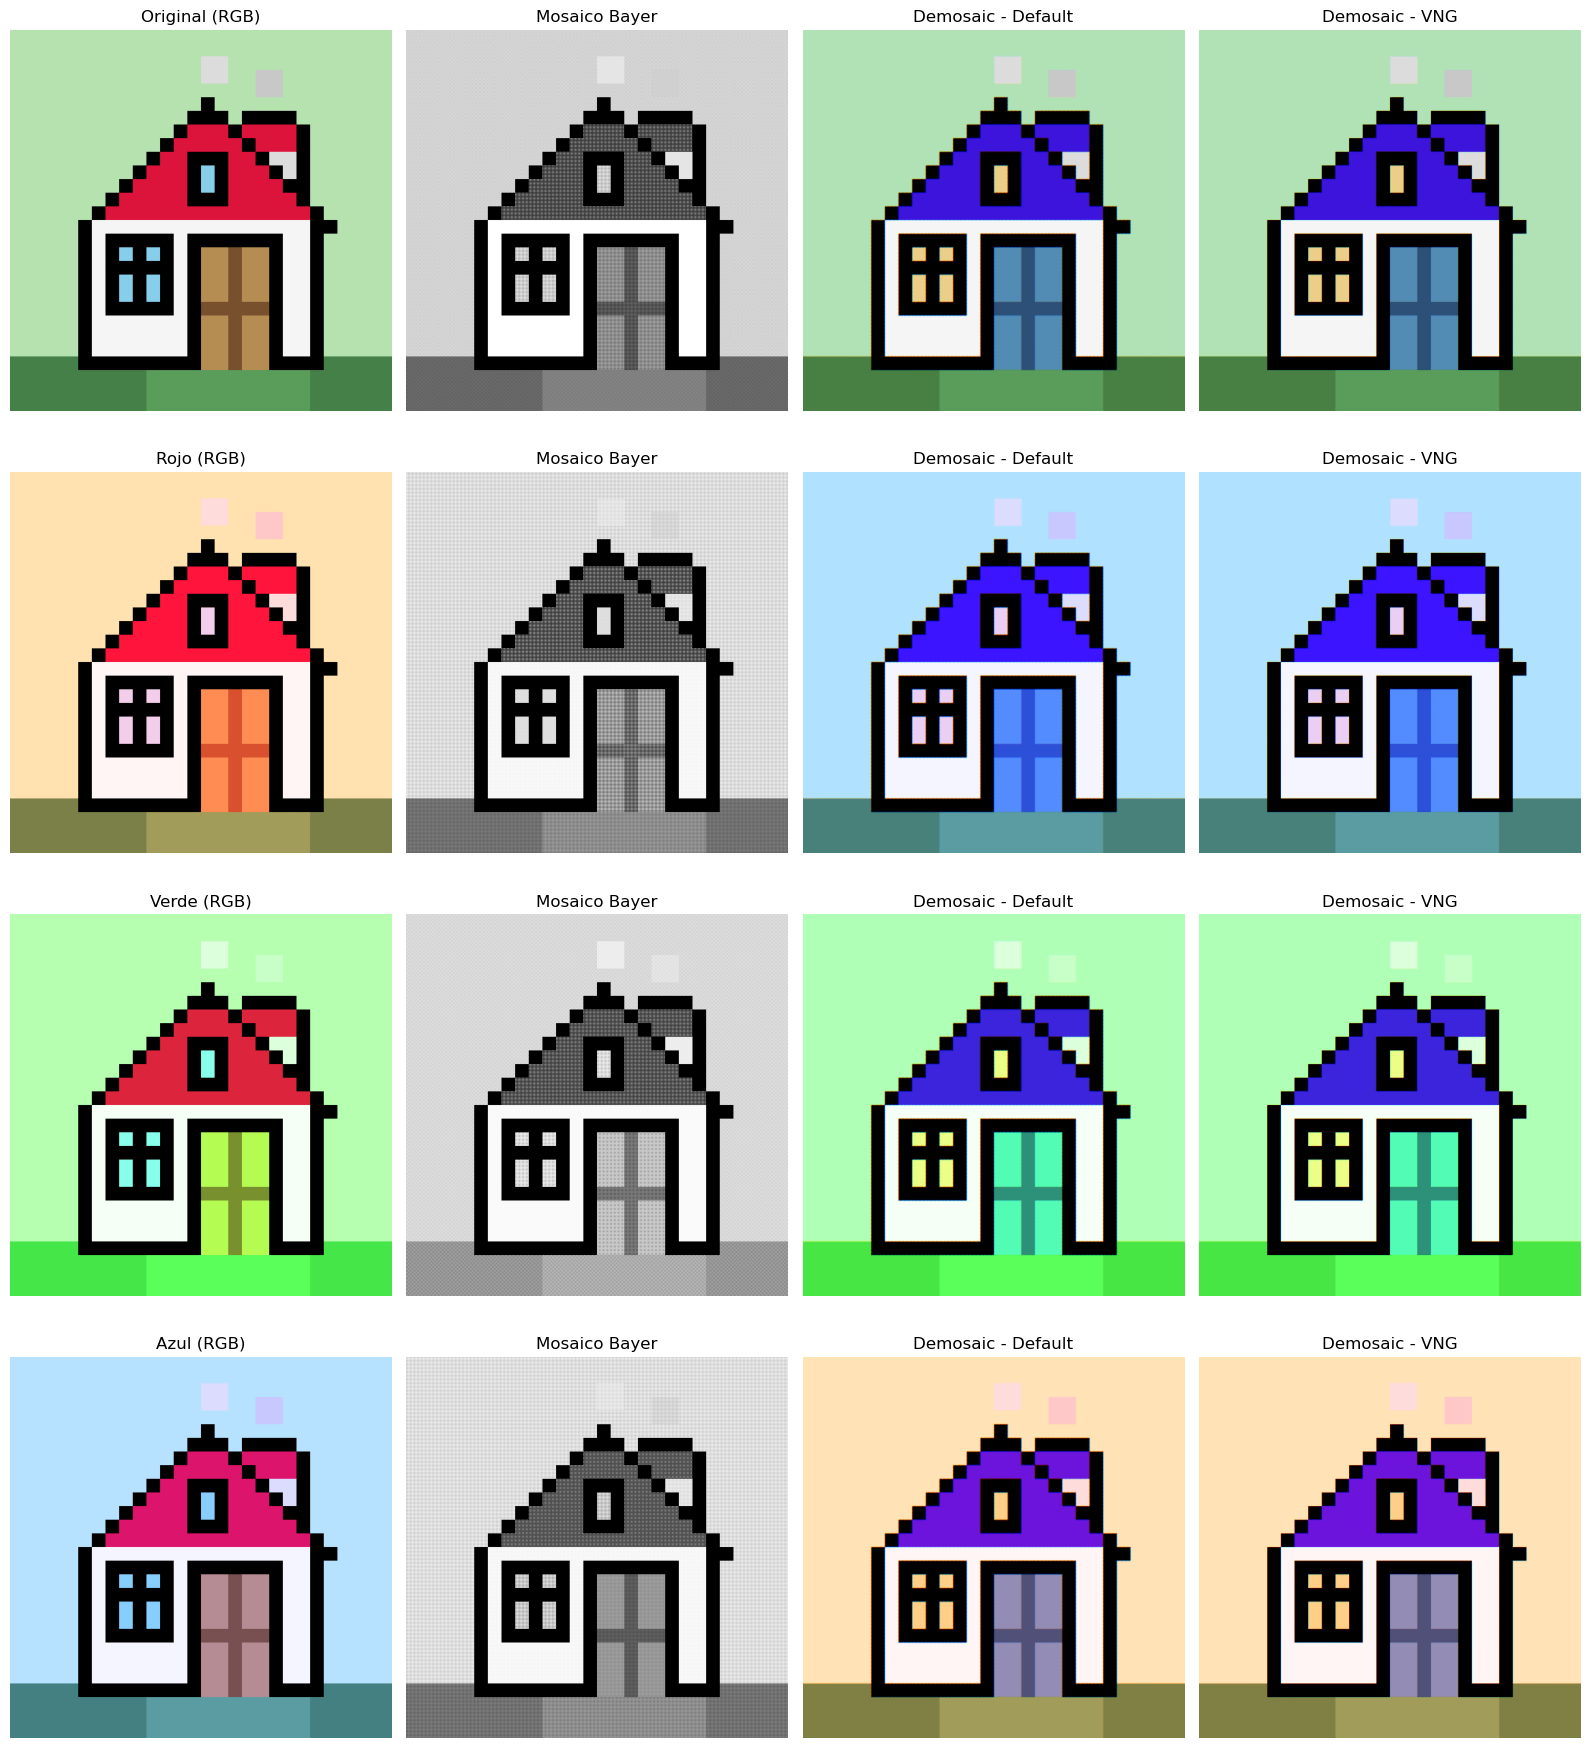

Resultados del ejercicio 6 guardados en: D:\PDI26\pdi26\salidas_practica5_pdf


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

if 'salida' not in globals():
    salida = Path('salidas_practica5_pdf')
    salida.mkdir(exist_ok=True)

lado = 20
filas, cols = 28, 28
lienzo = np.zeros((filas, cols, 3), dtype=np.uint8)

# Fondo:
lienzo[:] = (182, 226, 176)

def pintar_rect(img, r0, r1, c0, c1, color):
    img[r0:r1, c0:c1] = color

# Paleta RGB usada en la casita
NEGRO = (0, 0, 0)
BLANCO = (245, 245, 245)
ROJO_TECHO = (220, 20, 60)
VERDE_PASTO = (68, 128, 72)
VERDE_PASTO_CLARO = (90, 156, 90)
AMARILLO_VENTANA = (135, 206, 235)
MARRON_PUERTA = (181, 140, 82)
MARRON_SOMBRA = (120, 80, 45)
GRIS_HUMO1 = (220, 220, 220)
GRIS_HUMO2 = (200, 200, 200)

# ===== CESPED =====
pintar_rect(lienzo, 24, 28, 0, 10, VERDE_PASTO)
pintar_rect(lienzo, 23, 28, 10, 22, VERDE_PASTO_CLARO)
pintar_rect(lienzo, 24, 28, 22, 28, VERDE_PASTO)

# ===== CUERPO DE LA CASA =====
pintar_rect(lienzo, 14, 25, 6, 22, BLANCO)
pintar_rect(lienzo, 14, 25, 5, 6, NEGRO)
pintar_rect(lienzo, 13, 25, 22, 23, NEGRO)
pintar_rect(lienzo, 24, 25, 5, 23, NEGRO)

# ===== TECHO PRINCIPAL =====
for r in range(5, 14):
    izq = 14 - (r - 5)
    der = 14 + (r - 5)
    pintar_rect(lienzo, r, r + 1, izq, der, ROJO_TECHO)

pintar_rect(lienzo, 6, 7, 14, 15, NEGRO)
pintar_rect(lienzo, 7, 8, 13, 16, ROJO_TECHO)
pintar_rect(lienzo, 8, 9, 12, 17, ROJO_TECHO)

for r in range(5, 15):
    izq = 14 - (r - 5)
    der = 15 + (r - 5)
    pintar_rect(lienzo, r, r + 1, izq, izq + 1, NEGRO)
    pintar_rect(lienzo, r, r + 1, der - 1, der, NEGRO)

# ===== VENTANA FRONTAL =====
pintar_rect(lienzo, 16, 20, 8, 11, AMARILLO_VENTANA)
pintar_rect(lienzo, 15, 20, 7, 8, NEGRO)
pintar_rect(lienzo, 15, 20, 9, 10, NEGRO)
pintar_rect(lienzo, 15, 20, 11, 12, NEGRO)
pintar_rect(lienzo, 15, 16, 7, 12, NEGRO)
pintar_rect(lienzo, 17, 18, 7, 12, NEGRO)
pintar_rect(lienzo, 20, 21, 7, 12, NEGRO)

# ===== VENTANA DEL TECHO =====
pintar_rect(lienzo, 9, 13, 13, 16, AMARILLO_VENTANA)
pintar_rect(lienzo, 9, 13, 13, 14, NEGRO)
pintar_rect(lienzo, 9, 13, 15, 16, NEGRO)
pintar_rect(lienzo, 9, 10, 13, 16, NEGRO)
pintar_rect(lienzo, 12, 13, 13, 16, NEGRO)

# ===== PUERTA =====
pintar_rect(lienzo, 16, 25, 14, 19, MARRON_PUERTA)
pintar_rect(lienzo, 15, 25, 13, 14, NEGRO)
pintar_rect(lienzo, 15, 25, 19, 20, NEGRO)
pintar_rect(lienzo, 15, 16, 13, 20, NEGRO)
pintar_rect(lienzo, 20, 21, 14, 19, MARRON_SOMBRA)
pintar_rect(lienzo, 16, 25, 16, 17, MARRON_SOMBRA)

# ===== CHIMENEA =====
pintar_rect(lienzo, 6, 9, 18, 21, ROJO_TECHO)
pintar_rect(lienzo, 7, 8, 17, 21, ROJO_TECHO)
pintar_rect(lienzo, 9, 10, 19, 21, GRIS_HUMO1)
pintar_rect(lienzo, 10, 11, 20, 21, GRIS_HUMO1)
pintar_rect(lienzo, 7, 8, 16, 17, NEGRO)
pintar_rect(lienzo, 7, 13, 21, 22, NEGRO)
pintar_rect(lienzo, 6, 7, 17, 21, NEGRO)

# ===== HUMO =====
pintar_rect(lienzo, 2, 4, 14, 16, GRIS_HUMO1)
pintar_rect(lienzo, 3, 5, 18, 20, GRIS_HUMO2)

img_rgb = np.repeat(np.repeat(lienzo, lado, axis=0), lado, axis=1)
cv2.imwrite(str(salida / 'ej6_original_pixel_art.png'), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

def rgb_a_bayer(rgb, patron):
    h, w, _ = rgb.shape
    bayer = np.zeros((h, w), dtype=np.uint8)
    if patron == 'RGGB':
        bayer[0::2, 0::2] = rgb[0::2, 0::2, 0]
        bayer[0::2, 1::2] = rgb[0::2, 1::2, 1]
        bayer[1::2, 0::2] = rgb[1::2, 0::2, 1]
        bayer[1::2, 1::2] = rgb[1::2, 1::2, 2]
    elif patron == 'BGGR':
        bayer[0::2, 0::2] = rgb[0::2, 0::2, 2]
        bayer[0::2, 1::2] = rgb[0::2, 1::2, 1]
        bayer[1::2, 0::2] = rgb[1::2, 0::2, 1]
        bayer[1::2, 1::2] = rgb[1::2, 1::2, 0]
    elif patron == 'GBRG':
        bayer[0::2, 0::2] = rgb[0::2, 0::2, 1]
        bayer[0::2, 1::2] = rgb[0::2, 1::2, 2]
        bayer[1::2, 0::2] = rgb[1::2, 0::2, 0]
        bayer[1::2, 1::2] = rgb[1::2, 1::2, 1]
    elif patron == 'GRBG':
        bayer[0::2, 0::2] = rgb[0::2, 0::2, 1]
        bayer[0::2, 1::2] = rgb[0::2, 1::2, 0]
        bayer[1::2, 0::2] = rgb[1::2, 0::2, 2]
        bayer[1::2, 1::2] = rgb[1::2, 1::2, 1]
    return bayer

def potenciar_canal(rgb, canal, factor=1.8):
    salida_rgb = rgb.astype(np.float32).copy()
    salida_rgb[..., canal] = np.clip(salida_rgb[..., canal] * factor, 0, 255)
    return salida_rgb.astype(np.uint8)

demosaic_all = {
    'RGGB': cv2.COLOR_BAYER_RG2RGB,
    'BGGR': cv2.COLOR_BAYER_BG2RGB,
    'GBRG': cv2.COLOR_BAYER_GB2RGB,
    'GRBG': cv2.COLOR_BAYER_GR2RGB
}

for patron, cod in demosaic_all.items():
    mosaico = rgb_a_bayer(img_rgb, patron)
    reconstruida = cv2.cvtColor(mosaico, cod)
    cv2.imwrite(str(salida / f'ej6_{patron}_mosaico.png'), mosaico)
    cv2.imwrite(str(salida / f'ej6_{patron}_reconstruida.png'), cv2.cvtColor(reconstruida, cv2.COLOR_RGB2BGR))


patron_visual = 'RGGB'

if patron_visual == 'RGGB':
    cod_default = cv2.COLOR_BAYER_RG2RGB
    cod_vng = cv2.COLOR_BAYER_RG2RGB_VNG
elif patron_visual == 'BGGR':
    cod_default = cv2.COLOR_BAYER_BG2RGB
    cod_vng = cv2.COLOR_BAYER_BG2RGB_VNG
elif patron_visual == 'GBRG':
    cod_default = cv2.COLOR_BAYER_GB2RGB
    cod_vng = cv2.COLOR_BAYER_GB2RGB_VNG
else:
    cod_default = cv2.COLOR_BAYER_GR2RGB
    cod_vng = cv2.COLOR_BAYER_GR2RGB_VNG

variantes = [
    ('Original (RGB)', img_rgb),
    ('Rojo (RGB)', potenciar_canal(img_rgb, 0)),
    ('Verde (RGB)', potenciar_canal(img_rgb, 1)),
    ('Azul (RGB)', potenciar_canal(img_rgb, 2))
]

fig, axs = plt.subplots(4, 4, figsize=(16, 18))

for i, (titulo, variante) in enumerate(variantes):
    mosaico_var = rgb_a_bayer(variante, patron_visual)
    dem_default = cv2.cvtColor(mosaico_var, cod_default)
    dem_vng = cv2.cvtColor(mosaico_var, cod_vng)

    axs[i, 0].imshow(variante)
    axs[i, 0].set_title(titulo)
    axs[i, 0].axis('off')

    axs[i, 1].imshow(mosaico_var, cmap='gray')
    axs[i, 1].set_title('Mosaico Bayer')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(dem_default)
    axs[i, 2].set_title('Demosaic - Default')
    axs[i, 2].axis('off')

    axs[i, 3].imshow(dem_vng)
    axs[i, 3].set_title('Demosaic - VNG')
    axs[i, 3].axis('off')

plt.tight_layout()
plt.show()

print('Resultados del ejercicio 6 guardados en:', salida.resolve())